In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [15]:
df = pd.read_csv(
    "../assets/data/files/Vs.txt",
    sep="\s+",
)

df

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_128548/1896108842.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


,long,lat,depth,Vs
0,[degree],[degree],[km],[km/s]
1,50.0429864253,35.9795918367,.250,2.8755
2,50.1447963801,35.9795918367,.250,2.8645
3,50.2466063348,35.9795918367,.250,2.8514
4,50.3484162896,35.9795918367,.250,2.8412
...,...,...,...,...
87746,53.5045248869,34.5510204082,74.750,3.8196
87747,53.6063348416,34.5510204082,74.750,3.8144
87748,53.7081447964,34.5510204082,74.750,3.8082
87749,53.8099547511,34.5510204082,74.750,3.8021


In [23]:
data = df.drop(index=0).reset_index(drop=True)

In [24]:
data.shape

(87749, 4)

In [48]:
data = data.astype(np.float64)

In [49]:
X = data.drop(["Vs"], axis=1)
y = data["Vs"]

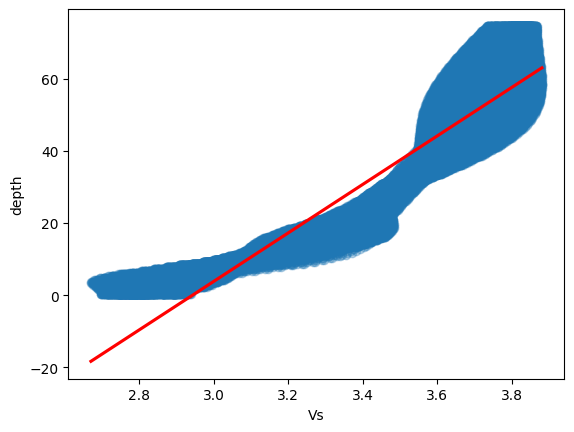

In [57]:
sns.regplot(x=y, y=X["depth"], line_kws={"color": "red"}, scatter_kws={"alpha": 0.3})
plt.show()

#### Regression


In [52]:
import numpy as np
import pandas as pd

from xgb.config import TrainingConfig
from xgb.trainer import run_training_pipeline

In [53]:
def training_config(model_path, output_dir):
    config = TrainingConfig(
        random_state=42,
        test_size=0.15,
        validation_size=0.15,
        use_early_stopping=True,
        early_stopping_rounds=50,
        cv_folds=5,
        model_path=model_path,
        output_dir=output_dir,
    )

    # Preprocessing settings
    config.preprocessing.numeric_imputer_strategy = "median"
    config.preprocessing.scaler = None
    config.preprocessing.ohe_min_frequency = 0.05

    # Optuna settings
    config.optuna.n_trials = 0
    config.optuna.sampler_name = "qmc"
    config.optuna.hpo_objective_metric = "rmse"

    return config

In [ ]:
Vs_res = run_training_pipeline(
    X=X,
    y=y,
    config=training_config("models_bin/Vs.joblib", "results/Vs_qmc"),
    verbose=True,
)

2025-08-13 13:10:20 - xgb.trainer - INFO - Starting MLflow Run: 6d4d848f31b74cb29b7c7c503ef1880a
2025-08-13 13:10:20 - xgb.trainer - INFO - 
Starting Training: Model=XGB, Target=Vs
MLflow Run ID: 6d4d848f31b74cb29b7c7c503ef1880a


2025-08-13 13:10:20 - xgb.trainer - INFO - Logged configuration to MLflow.
2025-08-13 13:10:20 - xgb.trainer - INFO - Initialized ModelTrainer for XGBoost with random_state: 42
2025-08-13 13:10:20 - xgb.trainer - INFO - Data split: Train=63398, Validation=11188, Test=13163
2025-08-13 13:10:20 - xgb.optimization - INFO - Skipping hyperparameter optimization (n_trials <= 0).
2025-08-13 13:10:20 - xgb.trainer - WARNING - Optuna did not find valid params. Using model defaults.
2025-08-13 13:10:20 - xgb.trainer - INFO - Starting final model training...
2025-08-13 13:10:20 - xgb.model_utils - INFO - Creating XGBRegressor instance with default hyperparameters.
2025-08-13 13:10:20 - xgb.trainer - INFO - Using early stopping with validation set and 50 rounds.


[0]	validation_0-rmse:0.21039	validation_0-mae:0.16908	validation_1-rmse:0.20952	validation_1-mae:0.16897
[1]	validation_0-rmse:0.14923	validation_0-mae:0.11913	validation_1-rmse:0.14878	validation_1-mae:0.11913
[2]	validation_0-rmse:0.10668	validation_0-mae:0.08459	validation_1-rmse:0.10646	validation_1-mae:0.08461
[3]	validation_0-rmse:0.07736	validation_0-mae:0.06092	validation_1-rmse:0.07733	validation_1-mae:0.06104
[4]	validation_0-rmse:0.05709	validation_0-mae:0.04464	validation_1-rmse:0.05714	validation_1-mae:0.04478
[5]	validation_0-rmse:0.04359	validation_0-mae:0.03387	validation_1-rmse:0.04374	validation_1-mae:0.03407
[6]	validation_0-rmse:0.03416	validation_0-mae:0.02640	validation_1-rmse:0.03442	validation_1-mae:0.02666
[7]	validation_0-rmse:0.02827	validation_0-mae:0.02169	validation_1-rmse:0.02854	validation_1-mae:0.02199
[8]	validation_0-rmse:0.02432	validation_0-mae:0.01863	validation_1-rmse:0.02468	validation_1-mae:0.01898
[9]	validation_0-rmse:0.02137	validation_0-mae

2025-08-13 13:10:32 - xgb.trainer - INFO - Final model training completed.
2025-08-13 13:10:32 - xgb.trainer - INFO - Successfully extracted and formatted training history.
2025-08-13 13:10:32 - xgb.model_utils - INFO - Creating XGBRegressor instance with default hyperparameters.
2025-08-13 13:10:32 - xgb.evaluation - INFO - Running 5-fold cross-validation with metrics: ['r2', 'mae', 'rmse']...
2025-08-13 13:10:34 - xgb.evaluation - INFO - Cross-validation completed.
2025-08-13 13:10:34 - xgb.interpretability - INFO - Starting SHAP value calculation...
2025-08-13 13:10:34 - xgb.interpretability - INFO - SHAP TreeExplainer created with background of size 100.
100%|===================| 13144/13163 [04:47<00:00]        2025-08-13 13:39:57 - xgb.interpretability - INFO - SHAP values calculated for train and test sets.
2025-08-13 13:39:58 - xgb.interpretability - INFO - Saved SHAP summary plot to results/Vs_qmc/shap_plots/xgb_shap_summary.png
2025-08-13 13:40:00 - xgb.interpretability - INF